# 2. Clasificación del dataset Iris con algoritmos de Machine Learning

En este notebook implementamos y comparamos tres algoritmos de clasificación sobre el dataset Iris:
- **A.** One Hot Encoding de las clases
- **B.** División dataset en train/test
- **C.** SVM, Random Forest y Naive Bayes + métricas
- **D.** Justificación del mejor modelo

In [9]:
# Instalación e importación de librerías
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Cargamos el dataset, comprobamos su estructura y visualizamos las primeras filas:
iris = sns.load_dataset('iris')
print('Forma/tamaño del dataset:', iris.shape)
iris.head()

Forma/tamaño del dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## 2A. One Hot Encoding de las clases

La columna `species` contiene tres clases categóricas: *setosa*, *versicolor* y *virginica*.
Aplicamos **One Hot Encoding** para convertirlas en vectores binarios, tal como requieren muchos algoritmos de ML, especialmente redes neuronales.

In [2]:

# En primer lugar definimos y separamos características (X) y etiquetas (y):
X_iris = iris.drop(columns=['species'])
y_iris = iris['species']


# Es recomendable comprobar la existencia de valores faltantes y outliers.
# En caso de existir, valoraremos si dejarlos o no en función del % del dataset
# que representan.

# Comprobación valores faltantes:

filas_con_nan = iris[iris.isna().any(axis=1)]

if filas_con_nan.empty:
    print("Este dataset no contiene valores faltantes.")
else:
    print("Se han detectado valores faltantes en las siguientes filas:")
    print(filas_con_nan)

# Con esto veríamos aquellas filas que tienen al menos un número faltante.
# Como vemos, en este dataset no existen valores faltantes.
# En el caso que hubiera aparecido alguno y quisiéramos quitar las filas
# afectadas usaríamos: iris = iris.dropna(); alternativamente
# podríamos imputar valores para evitar perder datos de otras columnas.



# Comprobación de outliers (valores extremos), que podrían darse por ejemplo
# como consecuencia de errores en las mediciones, pero también ocurrir
# de forma natural. Para ello usamos el método IQR, en que un dato se considera
# outlier si cae fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# donde IQR = Q3 - Q1 (rango intercuartílico):

print('\nDetección de outliers por el método IQR:')
outlier_indices = set()

for col in X_iris.columns:
    Q1  = X_iris[col].quantile(0.25)   # primer cuartil (25%)
    Q3  = X_iris[col].quantile(0.75)   # tercer cuartil (75%)
    IQR = Q3 - Q1                 # rango intercuartílico

    lim_inf = Q1 - 1.5 * IQR     # límite inferior
    lim_sup = Q3 + 1.5 * IQR     # límite superior

    # Filas que caen fuera de los límites
    outliers = X_iris[(X_iris[col] < lim_inf) | (X_iris[col] > lim_sup)]

    print(f'\n{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Rango válido: [{lim_inf:.2f}, {lim_sup:.2f}]')
    print(f'  Outliers encontrados: {len(outliers)}')

    if len(outliers) > 0:
        print(f'  Índices: {list(outliers.index)}')
        outlier_indices.update(outliers.index)

print(f'\nTotal de filas con al menos un outlier: {len(outlier_indices)}')
print(f'Índices: {sorted(outlier_indices)}')

# Decidimos no eliminar filas con outliers para evitar perder datos de otras mediciones.

# A continuación realizamos el One Hot Encoding de las etiquetas (variable 'species'):
y_enc = pd.get_dummies(iris['species'], dtype=int)

# Mostramos el resultado
print('\nUna vez realizado el One-hot encoding, obtenemos:')
print(f'\nVisualización primeras 5 entradas:')
print(y_enc.head())
print(f'\nVisualización entradas 80-84:')
print(y_enc.iloc[80:85])
print(f'\nVisualización últimas 5entradas:')
print(y_enc.tail())

Este dataset no contiene valores faltantes.

Detección de outliers por el método IQR:

sepal_length:
  Q1=5.10, Q3=6.40, IQR=1.30
  Rango válido: [3.15, 8.35]
  Outliers encontrados: 0

sepal_width:
  Q1=2.80, Q3=3.30, IQR=0.50
  Rango válido: [2.05, 4.05]
  Outliers encontrados: 4
  Índices: [15, 32, 33, 60]

petal_length:
  Q1=1.60, Q3=5.10, IQR=3.50
  Rango válido: [-3.65, 10.35]
  Outliers encontrados: 0

petal_width:
  Q1=0.30, Q3=1.80, IQR=1.50
  Rango válido: [-1.95, 4.05]
  Outliers encontrados: 0

Total de filas con al menos un outlier: 4
Índices: [15, 32, 33, 60]

Una vez realizado el One-hot encoding, obtenemos:

Visualización primeras 5 entradas:
   setosa  versicolor  virginica
0       1           0          0
1       1           0          0
2       1           0          0
3       1           0          0
4       1           0          0

Visualización entradas 80-84:
    setosa  versicolor  virginica
80       0           1          0
81       0           1          0
82

Cada especie queda representada como un vector de tres posiciones (una por clase). En nuestro caso:
setosa = `[1, 0, 0]`, versicolor = `[0, 1, 0]`, virginica = `[0, 0, 1]`.

Para los modelos clasificadores usaremos `y` (etiquetas originales) en vez de `y_enc`, ya que `SVC`, `RandomForest` y `GaussianNB` de sklearn aceptan directamente etiquetas categóricas.

---
## 2B. División del dataset en Train / Test

Dividimos el dataset en dos conjuntos:
- Entrenamiento (80%): para que los modelos aprendan los patrones.
- Test (20%): para evaluar el rendimiento real sobre datos no vistos.

Con 150 muestras totales, un 20% de test nos da **30 muestras** (10 por clase), lo que es suficiente para obtener métricas fiables sin sacrificar demasiados datos de entrenamiento. Usamos `stratify` para garantizar que la proporción de clases se mantenga en ambos conjuntos.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=21,
    stratify=y_iris
)

print(f'Tamaño entrenamiento : {X_train.shape[0]} muestras ({X_train.shape[0]/len(X_iris)*100:.0f}%)')
print(f'Tamaño test          : {X_test.shape[0]} muestras ({X_test.shape[0]/len(X_iris)*100:.0f}%)')
print()
print('Distribución de clases en el subset train:')
print(y_train.value_counts())
print('\nDistribución de clases en el subset test:')
print(y_test.value_counts())

Tamaño entrenamiento : 120 muestras (80%)
Tamaño test          : 30 muestras (20%)

Distribución de clases en el subset train:
species
versicolor    40
virginica     40
setosa        40
Name: count, dtype: int64

Distribución de clases en el subset test:
species
versicolor    10
setosa        10
virginica     10
Name: count, dtype: int64


---
## 2C. Implementación, entrenamiento y evaluación de los modelos

Antes de empezar el entrenamiento, es necesario estandarizar los datos, aunque únicamente 'Support Vector Machine' lo requiere, ya que 'Random Forest' se basa en umbrales y 'Naive Bayes' utiliza media y varianza de cada variable.

A continuación procedemos a entrenar los tres modelos y calculamos Precisión, Recall y F1-score para cada clase, creando además Matrices de confusión y una tabla resumen del rendimiento de los tres modelos.

In [4]:
# En primer lugar definimos los algoritmos que usaremos y los guardamos
# en un diccionario, para poder iterar. En este paso incluimos el escalado en el
# modelo 'Support Vector Machine', en el cual utilizamos SVC para clasificación,
# con el kernel 'rbf'(este es el kernel por defecto en SVC, permite separar
# datos no lineales y crea “zonas de influencia” alrededor de cada punto).
# Para 'Random Forest' definimos el número de 'árboles' o n_estimators a 100,
# mientras que para 'Naive Bayes' funcionan bien los valores por defecto:

models = {
    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1.0, random_state=21))
    ]),

    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=21),

    'Naive Bayes': GaussianNB()
}

results = {} # aquí se guardan las predicciones de cada modelo

for name, model in models.items():
    #.fit() entrena el modelo con los datos de entrenamiento:
    model.fit(X_train, y_train)
    #.predict() genera predicciones para el conjunto de test:
    y_pred = model.predict(X_test)
    #guardamos las predicciones de cada modelo para usarlas después (matrices de confusión, tabla resumen):
    results[name] = y_pred


    print(f'  {name}')
    # classification_report muestra, por cada clase y en conjunto:
    #   - Precision: de todo lo que el modelo predijo como clase X, ¿cuánto era realmente X?
    #   - Recall:    de todos los ejemplos reales de clase X, ¿cuántos detectó el modelo?
    #   - F1-score:  media armónica de precision y recall (equilibra ambas métricas)
    #   - Support:   número de ejemplos reales de esa clase en el test
    print(classification_report(y_test, y_pred))
    print()

  Support Vector Machine
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Naive Bayes
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica      

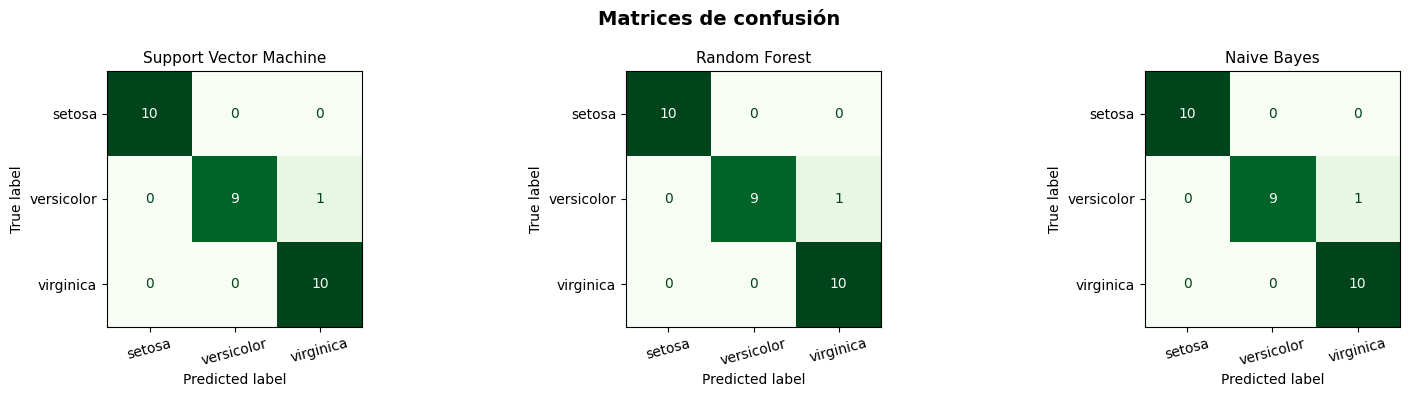

In [5]:
# A continuación creamos las Matrices de confusión, que muestran para
# cada clase real (filas), cuántas muestras fueron predichas en cada clase
# (columnas). La diagonal principal son los aciertos; el resto son errores.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Matrices de confusión', fontsize=14, fontweight='bold')

class_names = ['setosa', 'versicolor', 'virginica']

for ax, (name, y_pred) in zip(axes, results.items()):
    # Calculamos la matriz de confusión para este modelo
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    # Visualizamos con colores (intensidad color indica más muestras en esa celda)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


Como se observa en las matrices de confusión, los tres modelos predijeron mal una muestra de especie versicolor, clasificándola como virginica. Para comprobar si esto puede deberse a una mayor similitud entre estas dos especies, podemos visualizar las distribuciones (para cada característica) con la siguiente función:

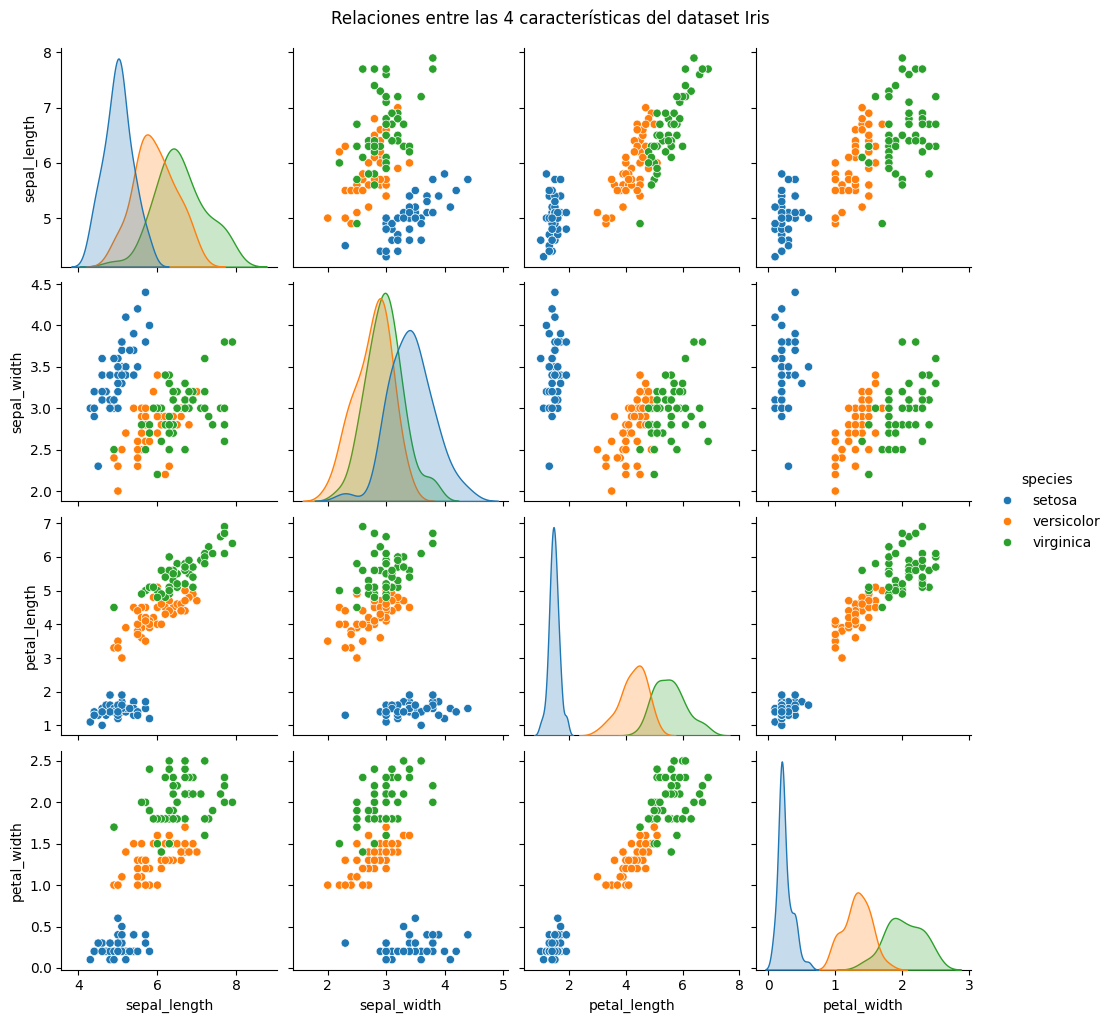

In [6]:
sns.pairplot(
    iris,
    hue='species',
    vars=[
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ]
)

plt.suptitle('Relaciones entre las 4 características del dataset Iris', y=1.02)
plt.show()

# Como se observa en los gráficos generados, las especies versicolor y virginica
# tienen características parcialmente solapantes, mientras que la especie setosa
# no presenta solapamiento en ninguna de las 4 características -es más distinta
# a las otras dos-, hecho que explica la mayor precisión de los modelos al predecirla.

In [7]:
# Por último construimos una tabla resumen de métricas. Calculamos las métricas
# globales de cada modelo usando el promedio macro (macro-avg), que trata todas
# las clases por igual, sin importar cuántas muestras tiene cada una
# (útil cuando las clases están equilibradas, como en este dataset)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\nResumen de métricas (macro-avg)')

summary = []
for name, y_pred in results.items():
    summary.append({
        'Modelo'   : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall'   : recall_score(y_test, y_pred, average='macro'),
        'F1-score' : f1_score(y_test, y_pred, average='macro'),
    })

df_summary = pd.DataFrame(summary).set_index('Modelo').round(4)
df_summary.style.highlight_max(axis=0, color='blue').format('{:.4f}')



Resumen de métricas (macro-avg)


,Accuracy,Precision,Recall,F1-score
Modelo,,,,
Support Vector Machine,0.9667,0.9697,0.9667,0.9666
Random Forest,0.9667,0.9697,0.9667,0.9666
Naive Bayes,0.9667,0.9697,0.9667,0.9666


Dado que el error cometido por los modelos se debe al solapamiento parcial de las especies versicolor y virginica, podemos intentar mejorar las predicciones aumentando el tamaño de muestras del entrenamiento o modificando hiperparámetros.

A continuación hemos vuelto a realizar la actividad adjudicando un 85% de las muestras al entrenamiento, para ver si así mejoraba la predicción del test (cuyo dataset se compondrá en este caso de un 15% de las muestras). Sin embargo, esta modifciación no ha evitado que los modelos sigan cometiendo el mismo error.

Otra alternativa que hemos probado ha sido modificar hiperparámetros:

-En SVM (SVC) hemos ajustado hiperparámetros con GridSearchCV:


In [8]:
from sklearn.model_selection import GridSearchCV

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

param_grid = {
    'svc__C'     : [0.1, 1, 10, 100],      # regularización: más alto = menos margen
    'svc__kernel': ['rbf', 'poly', 'linear'],
    'svc__gamma' : ['scale', 'auto']        # influencia de cada muestra
}

grid_search = GridSearchCV(pipeline_svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print('F1 macro en validación cruzada:', round(grid_search.best_score_, 4))

y_pred_best = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_best))



Mejores hiperparámetros: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
F1 macro en validación cruzada: 0.9666
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Como vemos, los hiperparámetros seleccionados como óptimos en SVM son los que ya habíamos aplicado, con lo que tampoco hemos podido mejorar la predicción.

---
## 2D. Justificación del mejor modelo

### Análisis de resultados

Los tres modelos presentan valores idénticos en todas las métricas.
Pese a la modificaciones efectuadas para intentar mejorar las prediccciones (aumento del tamaño de muestras del entrenamiento y modificación de hiperparámetros), éstas no han mejorado los resultados, lo que indica que el error cometido se debe a una limitación intrínseca del dataset, por solapamiento entre especies.


Situaciones en las que un modelo destacaría sobre los demás:

- **SVM**: cuando los datos son de alta dimensionalidad o cuando se necesita maximizar el margen de separación entre clases. Sin embargo, es menos interpretable y sensible a la elección del kernel y sus hiperparámetros.

- **Random Forest**: cuando se desea interpretabilidad (importancia de variables), cuando el dataset puede crecer, o cuando se quiere un modelo más robusto frente a outliers sin necesidad de escalar las features. Sin embargo, puede ser más lento en predicción en tiempo real.

- **Naive Bayes**: sería la mejor opción en escenarios donde la velocidad de entrenamiento es crítica (datos en streaming, dispositivos con recursos limitados) o cuando los datos son escasos, ya que converge con muy pocas muestras. Sin embargo, asume independencia entre features (puede resultar poco realista) y puede perder precisión si las variables están correlacionadas.
